# Label-shuffle decoding QC — permutation-test negative control

Aggregates the per-subject CSVs written by `run_label_shuffle_qc.py` and asks a
single question: **is category decoding driven by real signal, or could
comparable accuracy arise from shuffled labels (i.e. leakage/artifact)?**

- Decoding target: **stimulus category** (LinearSVC, accuracy, chance 0.25),
  same standardized-off decoder / LOGO-CV as `run_decoding.py`, on **type-D**
  betas only (the production betas everything downstream uses) — this is not a
  beta-version comparison (see `betas_qc_decoding.ipynb` for that), it's a
  sanity check on the production decoding numbers themselves.
- For each subject x mask: one **true-label** accuracy (`permutation == 0`) and
  `N_PERMUTATIONS` **shuffled-label** accuracies (labels permuted globally
  across all trials, same grouped CV). Runs on both a whole-brain mask and the
  visual-cortex ROI.
- **Expected result**: shuffled accuracy collapses to chance (~0.25) while true
  accuracy sits clearly above it. If shuffled accuracy stays elevated, that's a
  leakage red flag (e.g. standardization/feature selection fit before the CV
  split, autocorrelation between adjacent trials, motion/physio confounds
  correlated with condition order) — not something a shuffle test should be
  able to "beat".

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory holding the per-subject sub-*/sub-*_label_shuffle_qc.csv files
# (the --output-dir passed to run_label_shuffle_qc.py). Edit for your filesystem.
QC_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/glmsingle_qc")

MASKS = ["wholebrain", "visualcortex"]

In [2]:
# Load and concatenate all per-subject QC CSVs
csvs = sorted(glob.glob(str(QC_DIR / "sub-*" / "sub-*_label_shuffle_qc.csv")))
assert csvs, f"No label-shuffle QC CSVs found under {QC_DIR}"
df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)

n_sub = df["subject"].nunique()
n_perm = df["permutation"].max()
print(f"{n_sub} subjects, {n_perm} permutations/subject/mask, masks: {sorted(df['mask'].unique())}")
df.head()

59 subjects, 100 permutations/subject/mask, masks: ['visualcortex', 'wholebrain']


,subject,mask,target,permutation,shuffled,metric,value,baseline
0,sub-01,wholebrain,category,0,False,accuracy,0.338415,0.25
1,sub-01,wholebrain,category,1,True,accuracy,0.237805,0.25
2,sub-01,wholebrain,category,2,True,accuracy,0.231707,0.25
3,sub-01,wholebrain,category,3,True,accuracy,0.301829,0.25
4,sub-01,wholebrain,category,4,True,accuracy,0.262195,0.25


In [3]:
# Per-subject x mask summary: true accuracy vs the shuffled null (mean/sd/95th
# pct) and an empirical p-value = (# shuffles >= true + 1) / (N_perm + 1)
# (Combrisson & Jerbi, 2015 — never report p=0 from a finite permutation set).
def summarize(group):
    true_acc = group.loc[~group["shuffled"], "value"].iloc[0]
    null = group.loc[group["shuffled"], "value"]
    n_geq = (null >= true_acc).sum()
    return pd.Series({
        "true_acc": true_acc,
        "null_mean": null.mean(),
        "null_std": null.std(ddof=1),
        "null_p95": null.quantile(0.95),
        "p_value": (n_geq + 1) / (len(null) + 1),
    })

subject_summary = (df.groupby(["subject", "mask"])
                      .apply(summarize, include_groups=False)
                      .reset_index())
subject_summary.head()

,subject,mask,true_acc,null_mean,null_std,null_p95,p_value
0,sub-01,visualcortex,0.533537,0.247226,0.029378,0.296189,0.009901
1,sub-01,wholebrain,0.338415,0.256677,0.029277,0.301829,0.009901
2,sub-02,visualcortex,0.844512,0.250976,0.030025,0.304878,0.009901
3,sub-02,wholebrain,0.524390,0.250122,0.026312,0.289634,0.009901
4,sub-03,visualcortex,0.469512,0.246890,0.027200,0.289787,0.009901


In [4]:
# Group-level check: are subjects reliably above their own null? Count how
# many subjects clear a conventional p < .05 threshold, per mask.
for msk in MASKS:
    s = subject_summary[subject_summary["mask"] == msk]
    n_sig = (s["p_value"] < 0.05).sum()
    print(f"=== {msk} ===")
    print(f"  true accuracy:    {s['true_acc'].mean():.3f} ± {s['true_acc'].std(ddof=1):.3f}  (group mean ± sd, n={len(s)})")
    print(f"  null mean:        {s['null_mean'].mean():.3f} ± {s['null_mean'].std(ddof=1):.3f}  (chance = 0.25)")
    print(f"  subjects p<.05:   {n_sig}/{len(s)}")
subject_summary.groupby("mask")[["true_acc", "null_mean", "null_std", "p_value"]].mean()

=== wholebrain ===
  true accuracy:    0.368 ± 0.064  (group mean ± sd, n=59)
  null mean:        0.251 ± 0.005  (chance = 0.25)
  subjects p<.05:   51/59
=== visualcortex ===
  true accuracy:    0.483 ± 0.096  (group mean ± sd, n=59)
  null mean:        0.251 ± 0.005  (chance = 0.25)
  subjects p<.05:   59/59


,true_acc,null_mean,null_std,p_value
mask,,,,
visualcortex,0.483309,0.250691,0.027996,0.009901
wholebrain,0.368024,0.251141,0.027617,0.032220


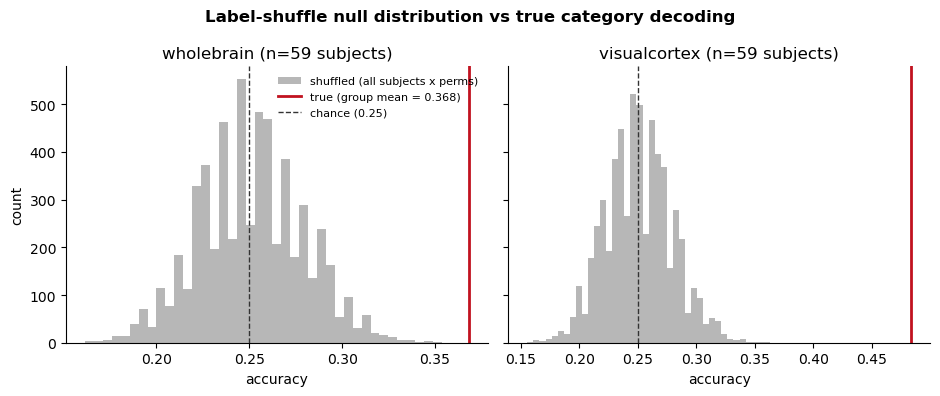

In [5]:
# Pooled null distribution (all subjects x all shuffles) vs the group-mean true
# accuracy, one panel per mask. Chance (0.25) marked for reference.
ACCENT = "#c1121f"  # same accent used in betas_qc_decoding.ipynb

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0), sharey=True)

for ax, msk in zip(axes, MASKS):
    null_vals = df.loc[(df["mask"] == msk) & df["shuffled"], "value"]
    true_mean = subject_summary.loc[subject_summary["mask"] == msk, "true_acc"].mean()
    baseline = df["baseline"].iloc[0]

    ax.hist(null_vals, bins=40, color="0.6", alpha=0.7, edgecolor="none",
            label="shuffled (all subjects x perms)")
    ax.axvline(true_mean, color=ACCENT, lw=2, label=f"true (group mean = {true_mean:.3f})")
    ax.axvline(baseline, ls="--", color="0.2", lw=1, label=f"chance ({baseline:g})")
    ax.set_xlabel("accuracy")
    ax.set_title(f"{msk} (n={subject_summary['subject'].nunique()} subjects)")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("count")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Label-shuffle null distribution vs true category decoding", fontweight="bold")
fig.tight_layout()
plt.show()

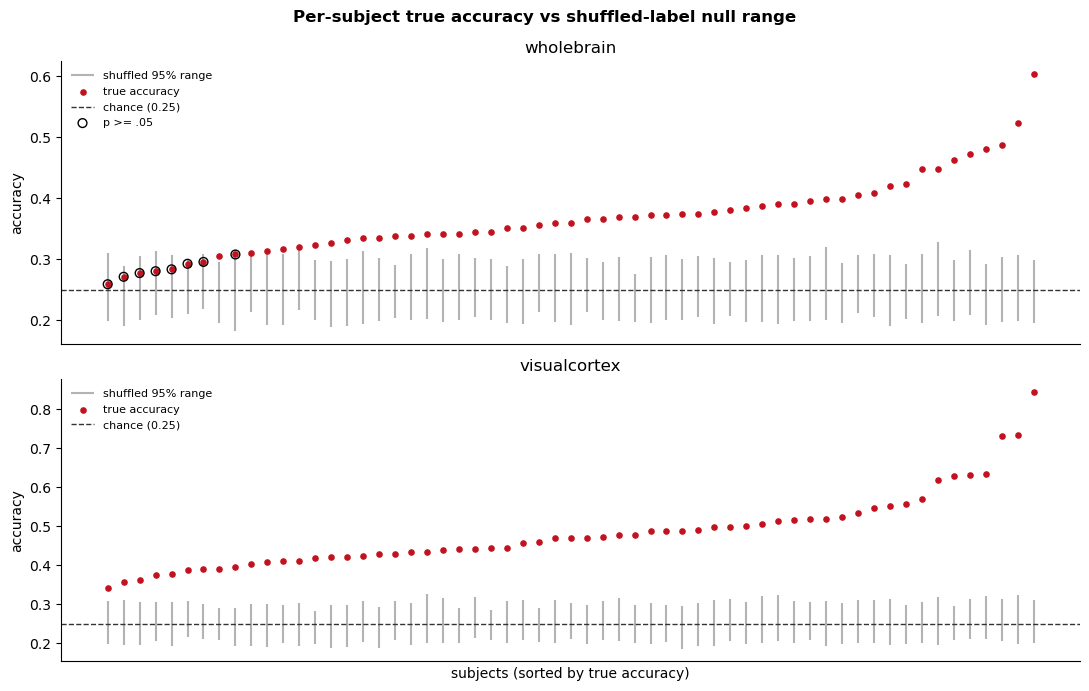

In [6]:
# Per-subject view: each subject's null range (2.5-97.5th percentile whisker,
# grey) vs their true accuracy (red dot), sorted by true accuracy. A subject
# whose true accuracy falls inside its own null range is a p >= .05 flag.
CHANCE = 0.25

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

for ax, msk in zip(axes, MASKS):
    s = subject_summary[subject_summary["mask"] == msk].sort_values("true_acc").reset_index(drop=True)
    null_lo = df[(df["mask"] == msk) & df["shuffled"]].groupby("subject")["value"].quantile(0.025)
    null_hi = df[(df["mask"] == msk) & df["shuffled"]].groupby("subject")["value"].quantile(0.975)
    s["null_lo"] = s["subject"].map(null_lo)
    s["null_hi"] = s["subject"].map(null_hi)

    x = np.arange(len(s))
    ax.vlines(x, s["null_lo"], s["null_hi"], color="0.7", lw=1.5, zorder=1,
              label="shuffled 95% range")
    ax.scatter(x, s["true_acc"], color=ACCENT, s=14, zorder=2, label="true accuracy")
    ax.axhline(CHANCE, ls="--", color="0.2", lw=1, label=f"chance ({CHANCE:g})")
    not_sig = s["p_value"] >= 0.05
    if not_sig.any():
        ax.scatter(x[not_sig], s.loc[not_sig, "true_acc"], facecolors="none",
                   edgecolors="k", s=40, zorder=3, label="p >= .05")

    ax.set_title(f"{msk}")
    ax.set_ylabel("accuracy")
    ax.set_xticks([])
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="upper left")

axes[-1].set_xlabel("subjects (sorted by true accuracy)")
fig.suptitle("Per-subject true accuracy vs shuffled-label null range", fontweight="bold")
fig.tight_layout()
plt.show()